# Support Vector Machine Model of NBA All-Star Predictions: 

## Libraries/Requirements: 

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, precision_score,
    recall_score, f1_score, accuracy_score
)
from pathlib import Path

from svm_pipelines import *

## Hyperparameter Selection: 

In [2]:
class Config:
    """
        Configuration for SVM model.
        Focuses on using the decision boundary distance to rank players.
        Controls:
            - regularization strength search (C_VALUES)
            - solver and optimization settings
            - temporal data splits
        Notes:
            - C_VALUES spans multiple orders of magnitude to test regularization sensitivity
    """
    SEED = 47
    C_VALUES = np.logspace(-5, 2, 15)
    KERNEL = 'linear'
    TRAIN_END = 2015
    VAL_END = 2021
    MAX_ITER = 100000
    TOL = 1e-3
    PROBABILITY = False

def get_project_root():
    """
        Dynamically locates the project root directory.
        Searches upward from the current working directory until a folder
        containing 'source/' is found. This avoids hardcoded paths and
        ensures portability across environments.
        Raises:
            FileNotFoundError if the expected project structure is not found.
    """
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / "source").exists(): 
            return parent
    raise FileNotFoundError("Could not find project root (missing 'source' folder)")

ROOT = get_project_root()
DATA_PATH = ROOT / "source" / "cleaned" / "cleaned_data.csv"

This SVM approach treats NBA All-Star selection as a spatial geometry problem. The model's primary objective is to construct a maximum-margin hyperplane—a multidimensional boundary that creates the widest possible "buffer zone" between elite All-Stars and the rest of the league.

| Component        | Parameter        | Value | Meaning |
|------------------|------------------|-------|--------|
| Reproducibility  | Seed             | 47 | Fixes randomness for consistent results |
| Model Selection  | C Values         | logspace(-5, 2) | Grid over regularization strengths |
| Optimization     | Max Iterations   | 100000 | Ensures convergence |
| Optimization     | Tolerance        | 1e-3 | Convergence threshold |
| Data Split       | Train End        | 2015 | Training cutoff year |
| Data Split       | Val End          | 2021 | Validation cutoff year |
| Data             | Path             | relative to root | Ensures portability across environments |
| Infrastructure   | Project Root     | auto-detected | Avoids hardcoded paths |

## Data Pipeline:

In [ ]:
class DataPipeline:
    """
        End-to-end data processing pipeline for the support vector machine model.
        This pipeline handles:
        1. Feature engineering (contextual + interaction-based features), allows for none
        2. Temporal train/validation/test splitting
        3. Missing value imputation
        4. Within-group normalization (season + conference)
        5. Global feature scaling
        Design principles:
            - All features are constructed relative to a player's competitive context
            (i.e., within the same season and conference).
            - Group-centering removes global scale effects and forces the model to
            learn *relative differences*, which aligns with the selection process.
            - The pipeline is fit only on training data and applied consistently
            to validation/test to prevent leakage.
        Key transformations:
            - Usage metrics:
                Usage = FGA + 0.44 * FTA
            - Winning-adjusted impact:
                Impact_on_winning = PTS × Team Win %
            - Contextual normalization:
                PTS_conf_z, Impact_conf_z (z-scores within group)
                PTS_conf_share (relative to group max)
            - Interaction features:
                Usage_x_Win, Win_x_AST, Win_x_TRB
            - Temporal features:
                AllStar_Last_Year, AllStar_last_2
            - Group-relative ranking:
                Usage_rank_conf
                Methods:
                    load(path, no_feature_flag):
                        Reads raw CSV and applies feature engineering (if wanted).
                    split(df):
                        Splits data chronologically into train / validation / test sets.
                    prepare(train_df, val_df, test_df):
                        - Drops non-feature columns
                        - Applies imputation (median)
                        - Applies group-centering (season, conference)
                        - Applies standard scaling
                        - Returns processed arrays + original dataframes
                    Notes:
                    - Group-centering is critical: it ensures the model compares players
                    within the same selection pool rather than across seasons.
                    - Feature names are stored for interpretability (used in coefficient analysis).
    """
    def __init__(self, cfg):
        self.cfg = cfg
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='median')

    def load(self, path, no_feature_flag = False):
        df = pd.read_csv(path)
        if no_feature_flag:
            return df
        return self._features(df)

    def _features(self, df):
        group_keys = ['Season Ending Year', 'Conference_East']

        df['Usage'] = df['FGA per game'] + 0.44 * df['FTA per game']
        df['Usage_x_Win'] = df['Usage'] * df['Team Win %']
        df['Impact_on_winning'] = df['PTS per game'] * df['Team Win %']

        pts_mean = df.groupby(group_keys)['PTS per game'].transform('mean')
        pts_std  = df.groupby(group_keys)['PTS per game'].transform('std')

        df['PTS_conf_z'] = (df['PTS per game'] - pts_mean) / (pts_std + 1e-8)
        df['PTS_minus_conf_avg'] = df['PTS per game'] - pts_mean

        pts_max = df.groupby(group_keys)['PTS per game'].transform('max')
        df['PTS_conf_share'] = df['PTS per game'] / (pts_max + 1e-8)

        impact_mean = df.groupby(group_keys)['Impact_on_winning'].transform('mean')
        impact_std  = df.groupby(group_keys)['Impact_on_winning'].transform('std')

        df['Impact_conf_z'] = (
            (df['Impact_on_winning'] - impact_mean) / (impact_std + 1e-8)
        )

        df['Usage_rank_conf'] = df.groupby(group_keys)['Usage'].rank(pct=True)

        df['Win_x_AST'] = df['Team Win %'] * df['AST per game']
        df['Win_x_TRB'] = df['Team Win %'] * df['TRB per game']

        df = df.sort_values(['Player', 'Season Ending Year']).reset_index(drop=True)

        df['AllStar_Last_Year'] = df.groupby('Player')['All Star'].shift(1).fillna(0)
        df['AllStar_last_2'] = (
            df.groupby('Player')['All Star']
            .shift(1)
            .rolling(2)
            .sum()
            .fillna(0)
        )

        df['Impact_x_LastYear'] = df['Impact_on_winning'] * df['AllStar_Last_Year']

        df = df.replace([np.inf, -np.inf], np.nan)
        return df

    def split(self, df):
        train_df = df[df['Season Ending Year'] <= self.cfg.TRAIN_END].copy()
        val_df = df[(df['Season Ending Year'] > self.cfg.TRAIN_END) & (df['Season Ending Year'] <= self.cfg.VAL_END)].copy()
        test_df = df[df['Season Ending Year'] > self.cfg.VAL_END].copy()
        return train_df, val_df, test_df

    def _group_center(self, X, df):
        X_df = pd.DataFrame(X, index=df.index)

        group_means = X_df.groupby(
            [df['Season Ending Year'], df['Conference_East']]
        ).transform('mean')

        centered = (X_df - group_means).fillna(0.0)
        return centered.values

    def prepare(self, train_df, val_df, test_df):
        drop_cols = [
            'All Star', 'Player', 'Season Ending Year',
            'Prev All Stars', 'Conference_East',
            'PosGroup_Backcourt', 'PosGroup_Frontcourt'
        ]

        def split_xy(df):
            X = df.drop(columns=drop_cols)
            y = df['All Star']
            return X, y

        X_train_df, y_train = split_xy(train_df)
        X_val_df, y_val = split_xy(val_df)
        X_test_df, y_test = split_xy(test_df)

        self.feature_names = X_train_df.columns.tolist()

        X_train = self.imputer.fit_transform(X_train_df)
        X_val   = self.imputer.transform(X_val_df)
        X_test  = self.imputer.transform(X_test_df)

        X_train = self._group_center(X_train, train_df)
        X_val   = self._group_center(X_val, val_df)
        X_test  = self._group_center(X_test, test_df)

        X_train = self.scaler.fit_transform(X_train)
        X_val   = self.scaler.transform(X_val)
        X_test  = self.scaler.transform(X_test)

        return (
            X_train, y_train, train_df,
            X_val, y_val, val_df,
            X_test, y_test, test_df
        )

The model’s performance is driven primarily by feature design. By centering and normalizing within selection groups, the input space directly reflects how players are compared in practice rather than relying on raw statistics. Feature engineering is designed to encode relative performance rather than absolute statistics. Most transformations normalize player performance within each (season, conference) group, aligning the feature space with the selection process.

| Component        | Step                  | Operation | Meaning |
|------------------|----------------------|----------|--------|
| Feature Creation | Usage                | FGA + 0.44·FTA | Estimates offensive involvement |
| Feature Creation | Usage × Win          | Usage · Win% | Contextualizes volume with team success |
| Feature Creation | Impact               | PTS · Win% | Measures scoring contribution to winning |
| Normalization    | PTS Z-Score          | (PTS − mean) / std | Relative scoring within group |
| Normalization    | PTS Difference       | PTS − group mean | Absolute deviation from peers |
| Normalization    | PTS Share            | PTS / max | Share of team/conference scoring |
| Normalization    | Impact Z-Score       | standardized impact | Relative contribution to winning |
| Ranking Feature  | Usage Rank           | percentile rank | Relative usage within group |
| Interaction      | Win × AST            | Win% · AST | Playmaking on winning teams |
| Interaction      | Win × TRB            | Win% · TRB | Rebounding on winning teams |
| Temporal Feature | Last Year All-Star   | lag(1) | Captures persistence/reputation |
| Temporal Feature | Last 2 Years         | rolling sum | Captures sustained performance |
| Interaction      | Impact × Last Year   | interaction | Reinforces repeat All-Star signal |
| Cleaning         | Inf Handling         | → NaN | Prevents invalid values |
| Missing Data     | Imputation           | median | Robust to outliers |
| Centering        | Group Centering      | X − group mean | Removes global scale, keeps relative signal |
| Scaling          | Standardization      | mean=0, std=1 | Stabilizes optimization |
| Splitting        | Temporal Split       | train/val/test by year | Prevents leakage across seasons |
| Output           | Feature Matrix       | X | Structured numeric inputs |
| Output           | Labels               | y | Binary All-Star indicator |

## Selection criteria

In [4]:

def structured_selection(df):
    """
        Applies deterministic roster construction based on predicted probabilities.
        For each (season, conference) group:
            - Selects 2 backcourt + 3 frontcourt players as starters
            - Selects top 7 remaining players as reserves
        This enforces the structural constraints of All-Star selection:
            total = 12 players per conference
            positional quotas for starters
        Args:
            df (pd.DataFrame):
                Must contain:
                    - 'prob' (predicted probability)
                    - 'PosGroup_Backcourt'
                    - 'PosGroup_Frontcourt'
                    - grouping columns
        Returns:
            df (pd.DataFrame):
                Same dataframe with added column:
                - 'pred' (binary selection indicator)
        Notes:
            - This converts probabilistic predictions into a discrete roster.
            - Evaluation metrics (Top-K recall, accuracy, etc.) depend on this step.
            - The model itself is unconstrained; structure is enforced post hoc.
    """
    df = df.copy()
    df['pred'] = 0

    for (season, conf), group in df.groupby(['Season Ending Year', 'Conference_East']):
        bc = group[group['PosGroup_Backcourt'] == 1]
        fc = group[group['PosGroup_Frontcourt'] == 1]

        starters = pd.concat([
            bc.sort_values('prob', ascending=False).head(2),
            fc.sort_values('prob', ascending=False).head(3)
        ])

        remaining = group.drop(index=starters.index)
        reserves = remaining.sort_values('prob', ascending=False).head(7)

        selected = pd.concat([starters, reserves])
        df.loc[selected.index, 'pred'] = 1

    return df

## Training Loop: 

In [5]:
class SVMTrainer:
    """
        Handles hyperparameter tuning and training for SVM-based pipelines.
    
        The primary objective is to select the regularization strength (C)
        that maximizes the ranking accuracy within the specific constraints 
        of the NBA All-Star selection process.
        Tuning strategy:
            - Train a model for each C in the search grid
            - Evaluate on validation set using:
                (1) AUC → measures global ranking quality
                (2) Top-K Recall → measures correctness of final roster selection
            - Select C by prioritizing Top-K recall, with AUC as a tiebreaker
            This reflects the task structure:
            - The goal is not just classification, but selecting the correct
            subset of players under roster constraints.
        Methods:
            tune(pipeline_func, X_train, y_train, train_df, X_val, y_val, val_df):
                Performs grid search over C values based on a specific SVM model.
                Returns the best C based on (TopK, AUC).
            train_final(pipeline_func, C, X_train, y_train, train_df):
                Trains a final model on full training data using the chosen C.
        Notes:
            - Top-K recall is computed after structured_selection, making it
            directly aligned with the downstream decision process.
            - AUC ensures the model still maintains strong global ranking behavior.
            - No cross-validation is used; tuning is strictly time-based
            (train → validation split).
    """
    def __init__(self, cfg):
        self.cfg = cfg

    def tune(self, pipeline_func, X_train, y_train, train_df, X_val, y_val, val_df):
        """
        Args:
            pipeline_func: A function like get_base_pipeline or get_poly_pipeline
        """
        results = []

        for C in self.cfg.C_VALUES:
            pipeline = pipeline_func(self.cfg, c_val=C)
            pipeline.fit(X_train, y_train)

            scores = pipeline.decision_function(X_val)
            auc = roc_auc_score(y_val, scores)

            temp_df = val_df.copy()
            temp_df['prob'] = scores
            temp_df = structured_selection(temp_df)

            true_allstars = y_val.sum()
            selected_correct = ((temp_df['pred'] == 1) & (y_val == 1)).sum()
            topk_recall = selected_correct / (true_allstars + 1e-8)

            results.append((C, auc, topk_recall, pipeline))
            print(f"C={C:.5f} | AUC={auc:.4f} | TopK={topk_recall:.4f}")


        best_entry = sorted(results, key=lambda x: (x[2], x[1]), reverse=True)[0]
        
        best_C = best_entry[0]
        best_model = best_entry[3]
        
        print(f"\nBest C found: {best_C}")
        print(f"Best Validation TopK: {best_entry[2]:.4f}")
        
        return best_model, best_C, results

    def train_final(self, pipeline_func, C, X_train, y_train):
        """
        Trains the final chosen pipeline on the full training set.
        """
        final_pipeline = pipeline_func(self.cfg, c_val=C)
        final_pipeline.fit(X_train, y_train)
        return final_pipeline


Hyperparameter tuning is aligned with the downstream task: selecting the correct players, not just ranking them well. This shifts optimization from standard classification metrics toward structured decision quality. Model selection prioritizes structured performance rather than pure classification accuracy. Top-K recall is used as the primary objective, ensuring the model is optimized for actual roster construction.

| Component        | Step                  | Operation | Meaning |
|------------------|----------------------|----------|--------|
| Hyperparameter   | Regularization Grid  | C ∈ logspace(-3, 2) | Explores strength of L2 penalty |
| Training         | Model Fit            | fit(X_train, y_train) | Learns pointwise + pairwise weights |
| Inference        | Validation Scores    | predict_proba(X_val) | Produces calibrated probabilities |
| Ranking Metric   | AUC                  | roc_auc | Measures global ranking quality |
| Structured Eval  | Selection            | top-12 per group | Converts probabilities into roster |
| Selection Metric | Top-K Recall         | correct / true | Measures how many true All-Stars are selected |
| Model Selection  | Objective            | maximize (TopK, AUC) | Prioritizes selection quality over raw ranking |
| Output           | Best C               | argmax metric | Final regularization choice |
| Final Training   | Refit Model          | train on full train set | Uses best hyperparameter |

## Evaluation Functions: 

In [6]:
def evaluate(model, X_test, y_test, test_df):
    """
        Evaluates the trained model using both probabilistic and structured metrics.
        The evaluation proceeds in two stages:
            1. Generate probabilities for all players
            2. Apply structured_selection to form final rosters
        Metrics reported:
            - Global:
                AUC, Accuracy, Precision, Recall, F1
            - Per (season, conference):
                Same metrics + Top-K Recall + Top-12 Accuracy
            - Per season (overall):
                Aggregated metrics across both conferences
            - Final summary:
                Average per-season metrics
        Key definitions:
            - Top-K Recall:
                Fraction of true All-Stars correctly selected
            - Top-12 Accuracy:
                Fraction of selected players who are true All-Stars
        Args:
            model: Trained HybridModel
            X_test (np.ndarray): Test features
            y_test (pd.Series): Ground truth labels
            test_df (pd.DataFrame): Original dataframe (used for grouping + structure)
        Notes:
            - Structured selection enforces real roster constraints (2 BC, 3 FC starters + 7 reserves).
            - Metrics reflect both ranking quality (AUC) and discrete selection performance.
            - Per-group evaluation highlights variability across seasons and conferences.
    """
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
    else:
        scores = model.predict_proba(X_test)[:, 1]

    temp_df = test_df.copy()
    temp_df['prob'] = scores
    temp_df = structured_selection(temp_df)

    y_true = y_test.values
    y_pred = temp_df['pred'].values

    print("\n=== FINAL RESULTS ===")
    print("AUC:", roc_auc_score(y_true, scores))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print("\n=== Per-Season (Conference Split) ===")

    season_conf_metrics = []

    for (season, conf), group in temp_df.groupby(['Season Ending Year', 'Conference_East']):
        y_g = group['All Star'].values
        p_g = group['pred'].values
        prob_g = group['prob'].values

        if len(np.unique(y_g)) > 1:
            auc = roc_auc_score(y_g, prob_g)
        else:
            auc = np.nan

        acc = accuracy_score(y_g, p_g)
        prec = precision_score(y_g, p_g, zero_division=0)
        rec = recall_score(y_g, p_g, zero_division=0)
        f1 = f1_score(y_g, p_g, zero_division=0)

        true_allstars = y_g.sum()
        selected_correct = ((p_g == 1) & (y_g == 1)).sum()
        topk_recall = selected_correct / (true_allstars + 1e-8)

        total_selected = p_g.sum()
        top12_acc = selected_correct / (total_selected + 1e-8)

        season_conf_metrics.append((auc, acc, prec, rec, f1, topk_recall, top12_acc))

        print(
            f"{season} Conf {conf} | "
            f"AUC {auc:.4f} | "
            f"Acc {acc:.3f} | "
            f"P {prec:.3f} | R {rec:.3f} | F1 {f1:.3f} | "
            f"Top 12 Recall {topk_recall:.3f} | Top 12 Accuracy {top12_acc:.3f}"
        )

    print("\n=== Per-Season (Overall) ===")

    season_metrics = []

    for season, group in temp_df.groupby('Season Ending Year'):
        y_g = group['All Star'].values
        p_g = group['pred'].values
        prob_g = group['prob'].values

        if len(np.unique(y_g)) > 1:
            auc = roc_auc_score(y_g, prob_g)
        else:
            auc = np.nan

        acc = accuracy_score(y_g, p_g)
        prec = precision_score(y_g, p_g, zero_division=0)
        rec = recall_score(y_g, p_g, zero_division=0)
        f1 = f1_score(y_g, p_g, zero_division=0)

        true_allstars = y_g.sum()
        selected_correct = ((p_g == 1) & (y_g == 1)).sum()
        topk_recall = selected_correct / (true_allstars + 1e-8)

        total_selected = p_g.sum()
        top12_acc = selected_correct / (total_selected + 1e-8)

        season_metrics.append((auc, acc, prec, rec, f1, topk_recall, top12_acc))

        print(
            f"{season} | "
            f"AUC {auc:.4f} | "
            f"Acc {acc:.3f} | "
            f"P {prec:.3f} | R {rec:.3f} | F1 {f1:.3f} | "
            f"Top 12 Recall {topk_recall:.3f} | Top 12 Accuracy {top12_acc:.3f}"
        )

    season_metrics = np.array(season_metrics)

    print("\n=== Avg Per-Season Metrics ===")
    print("AUC            :", np.nanmean(season_metrics[:, 0]))
    print("Accuracy       :", season_metrics[:, 1].mean())
    print("Precision      :", season_metrics[:, 2].mean())
    print("Recall         :", season_metrics[:, 3].mean())
    print("F1             :", season_metrics[:, 4].mean())
    print("Top 12 Recall  :", season_metrics[:, 5].mean())
    print("Top 12 Accuracy:", season_metrics[:, 6].mean())


def print_feature_importance(model, feature_names, top_k=10):
    """
    Adjusted for SVM Pipeline.
    Extracts weights from the 'svm' step of the pipeline.
    """
    print("\n=== FEATURE IMPORTANCE (SVM GEOMETRIC WEIGHTS) ===")

    # 1. Reach into the pipeline to grab the actual SVM estimator
    # We assume your pipeline step was named 'svm'
    try:
        if hasattr(model, 'named_steps'):
            svm_step = model.named_steps['svm']
        else:
            svm_step = model
            
        coefs = svm_step.coef_.flatten()
    except AttributeError:
        print("Could not extract coefficients. Ensure the winner is a Linear SVM.")
        return

    # 2. Match coefficients to feature names
    if len(coefs) != len(feature_names):
        print(f"Warning: Model has {len(coefs)} weights, but {len(feature_names)} features.")
        print("This happens with PCA or Polynomial pipelines. Skipping mapping.")
        return

    df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)

    print("\nTop Positive Features (Strongest All-Star Drivers):")
    print(df.sort_values("coef", ascending=False).head(top_k)[["feature", "coef"]])

    print("\nTop Negative Features (Strongest Detractors):")
    print(df.sort_values("coef", ascending=True).head(top_k)[["feature", "coef"]])

Notably, several features (e.g., raw scoring metrics) appear negatively weighted after group-centering. This reflects that selection is driven more by *relative performance within a conference-season* than absolute values. 

Evaluation is split into two layers:  
(1) probabilistic ranking (AUC), and  
(2) structured roster construction (Top-K metrics).

Feature importance is examined separately for pointwise and pairwise models, allowing us to distinguish between:
- features that increase raw selection probability
- features that help a player outperform others within the same pool.

| Component | Step | Operation | Meaning |
|----------|------|----------|--------|
| Inference | Probability Prediction | predict_proba(X_test) | Produces calibrated likelihood of All-Star selection |
| Structured Decision | Selection | top-12 per (season, conference) | Enforces real roster constraints (2 BC, 3 FC, 7 reserves) |
| Global Metric | AUC | roc_auc_score | Measures overall ranking quality |
| Global Metric | Accuracy | accuracy_score | Measures classification correctness after selection |
| Global Metric | Precision | precision_score | Fraction of selected players who are true All-Stars |
| Global Metric | Recall | recall_score | Fraction of true All-Stars successfully selected |
| Global Metric | F1 | harmonic mean | Balances precision and recall |
| Group Evaluation | Per (Season, Conf) | grouped metrics | Measures consistency across selection pools |
| Selection Metric | Top-K Recall | correct / true | Measures how many All-Stars are captured |
| Selection Metric | Top-12 Accuracy | correct / selected | Measures quality of final roster |
| Aggregation | Per Season | grouped metrics | Evaluates stability across years |
| Summary | Avg Metrics | mean over seasons | Provides overall performance estimate |
| Interpretability | Pointwise Coefs | model.pointwise.coef_ | Measures direct feature impact on probability |
| Interpretability | Pairwise Coefs | model.pairwise.coef_ | Measures feature impact on ranking between players |
| Feature Ranking | Absolute Value | \|coef\| | Identifies strongest contributors |
| Positive Effects | coef > 0 | increases probability/rank | Feature pushes player toward selection |
| Negative Effects | coef < 0 | decreases probability/rank | Feature pushes player away from selection |

## Runtime: 

We'll start with a baseline SVM with none of the feature engineering and only from the original cleaned data.
We will then try a Polynomial Feature Transform on the original data.

Then, we will move on to the feature engineering and use the baseline and then Polynomial once again.

In [ ]:
"""
End-to-end training and evaluation pipeline for the SVM model.
Workflow:
    1. Initialize configuration and data pipeline
    2. Load and preprocess dataset
    3. Split data into train / validation / test (time-based)
    4. Prepare features (imputation, group-centering, scaling)
    5. Tune regularization strength (C) using validation data
    6. Train final model on full training set
    7. Inspect feature importance
    8. Evaluate on held-out test set using structured selection
Key design choices:
    - Time-based splits prevent leakage across seasons
    - Group-centered features ensure comparisons are made within
    (season, conference) selection pools
    - Hyperparameter tuning prioritizes Top-K recall, aligning with
    the roster selection objective
    - Final evaluation reflects real constraints via structured_selection
Outputs:
    - Best regularization parameter (C)
    - Feature importance rankings
    - Global and per-season performance metrics
Notes:
- The pipeline is fully reproducible given a fixed seed and data path

"""

In [13]:
cfg = Config()
trainer = SVMTrainer(cfg)


best_overall_model = None
best_overall_recall = -1
results_log = []

architectures = {
    "Baseline": get_base_pipeline,
    "Polynomial": get_poly_pipeline
}

for is_raw_data in (True, False):
    data_type = "RAW" if is_raw_data else "ENGINEERED"
    print(f"\n========== TESTING {data_type} DATA ==========")
    
    pipeline = DataPipeline(cfg)
    df = pipeline.load(DATA_PATH, no_feature_flag=is_raw_data)
    train_df, val_df, test_df = pipeline.split(df)

    (X_train, y_train, train_df, X_val, y_val, val_df, 
     X_test, y_test, test_df) = pipeline.prepare(train_df, val_df, test_df)

    for name, pipe_func in architectures.items():
        # Skip Polynomial on RAW data if you want to keep the experiment clean, 
        # or keep it to see if Poly can "discover" the features you manually made.
        print(f"\n>>> Tuning {name} on {data_type} stats...")
        
        model, best_c, tuning_history = trainer.tune(pipe_func, X_train, y_train, train_df, X_val, y_val, val_df)
        
        sorted_history = sorted(tuning_history, key=lambda h: (h[2], h[1]), reverse=True)
        best_trial = sorted_history[0]
        final_auc = best_trial[1]
        
        # Validation Eval
        scores = model.decision_function(X_val)
        temp_val = val_df.copy()
        temp_val['prob'] = scores
        temp_val = structured_selection(temp_val)
        
        current_recall = ((temp_val['pred'] == 1) & (val_df['All Star'] == 1)).sum() / (val_df['All Star'].sum() + 1e-8)
        
        # Save results with context
        results_log.append({
            "name": f"{name}_{data_type}",
            "model": model,
            "best_c": best_c,
            "auc": final_auc,
            "recall": current_recall,
            "tuning_history": tuning_history,
            "X_test": X_test, # Store the specific test array for this data version
            "y_test": y_test,
            "test_df": test_df,
            "feature_names": pipeline.feature_names
        })




========== TESTING RAW DATA ==========

>>> Tuning Baseline on RAW stats...
C=0.00001 | AUC=0.9749 | TopK=0.6821
C=0.00003 | AUC=0.9749 | TopK=0.6821
C=0.00010 | AUC=0.9735 | TopK=0.6821
C=0.00032 | AUC=0.9618 | TopK=0.6424
C=0.00100 | AUC=0.9649 | TopK=0.6623
C=0.00316 | AUC=0.9702 | TopK=0.6689
C=0.01000 | AUC=0.9752 | TopK=0.6887
C=0.03162 | AUC=0.9771 | TopK=0.7020
C=0.10000 | AUC=0.9767 | TopK=0.6887
C=0.31623 | AUC=0.9756 | TopK=0.6954


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C=1.00000 | AUC=0.9755 | TopK=0.7020


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C=3.16228 | AUC=0.9779 | TopK=0.6954


...

C=10.00000 | AUC=0.8381 | TopK=0.4901


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C=31.62278 | AUC=0.8381 | TopK=0.4901


/opt/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


C=100.00000 | AUC=0.8381 | TopK=0.4901

Best C found: 0.00031622776601683794
Best Validation TopK: 0.7550


In [14]:

# Find the absolute winner across all 4 combinations
winner = sorted(results_log, key=lambda x: (x['recall'], x['auc']), reverse=True)[0]
print(f"\n=== WINNING ARCHITECTURE: {winner['name']} ===")
print(f"Validation Top-K Recall: {winner['recall']:.4f}")

# Final Evaluation using the correct Test Set for that model
evaluate(winner['model'], winner['X_test'], winner['y_test'], winner['test_df'])

# Feature Importance only if the winner was a Baseline/Linear model
if "Baseline" in winner['name']:
    print_feature_importance(winner['model'], winner['feature_names'])


=== WINNING ARCHITECTURE: Polynomial_ENGINEERED ===
Validation Top-K Recall: 0.7550

=== FINAL RESULTS ===
AUC: 0.9803403185464536
Accuracy: 0.9665634674922601
Precision: 0.75
Recall: 0.7058823529411765
F1: 0.7272727272727272

=== Per-Season (Conference Split) ===
2022.0 Conf False | AUC 0.9375 | Acc 0.971 | P 0.750 | R 0.750 | F1 0.750 | Top 12 Recall 0.750 | Top 12 Accuracy 0.750
2022.0 Conf True | AUC 0.9843 | Acc 0.960 | P 0.750 | R 0.643 | F1 0.692 | Top 12 Recall 0.643 | Top 12 Accuracy 0.750
2023.0 Conf False | AUC 0.9850 | Acc 0.953 | P 0.667 | R 0.615 | F1 0.640 | Top 12 Recall 0.615 | Top 12 Accuracy 0.667
2023.0 Conf True | AUC 0.9816 | Acc 0.956 | P 0.667 | R 0.615 | F1 0.640 | Top 12 Recall 0.615 | Top 12 Accuracy 0.667
2024.0 Conf False | AUC 0.9833 | Acc 0.962 | P 0.667 | R 0.727 | F1 0.696 | Top 12 Recall 0.727 | Top 12 Accuracy 0.667
2024.0 Conf True | AUC 0.9896 | Acc 0.972 | P 0.833 | R 0.714 | F1 0.769 | Top 12 Recall 0.714 | Top 12 Accuracy 0.833
2025.0 Conf False

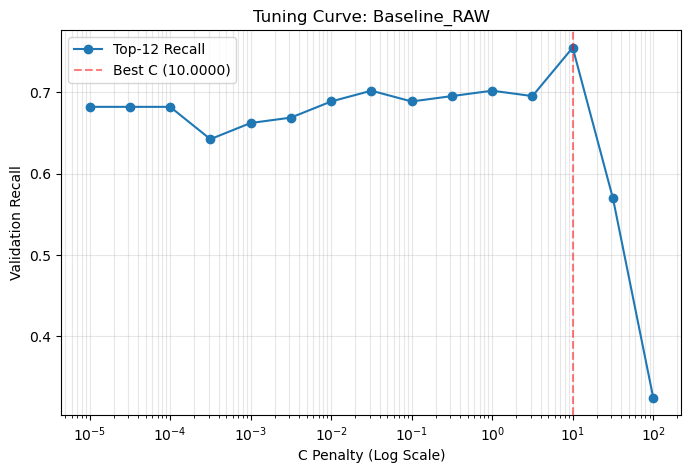

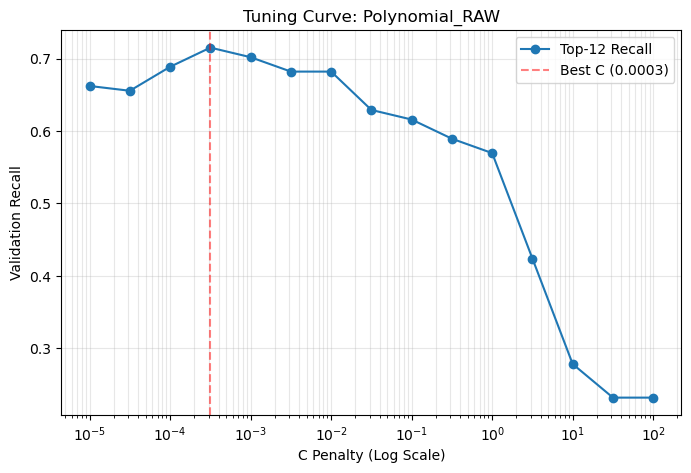

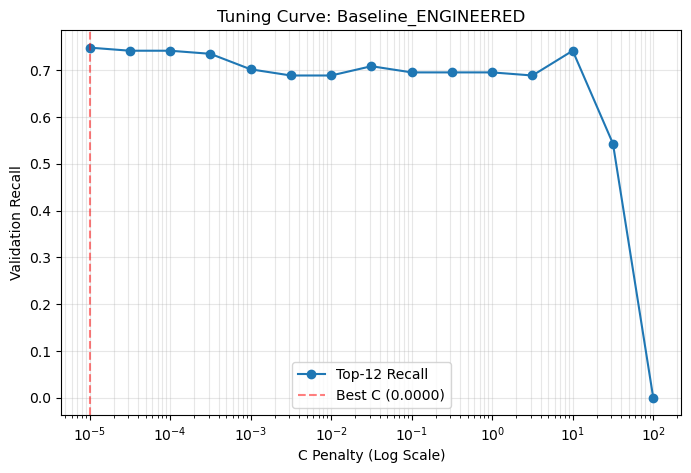

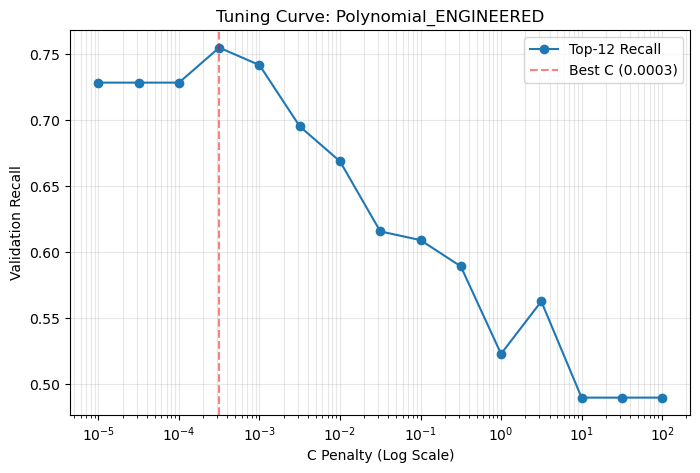

In [16]:

import matplotlib.pyplot as plt
for entry in results_log:
    # tuning_history is [(C, AUC, TopK, model), ...]
    history = entry['tuning_history']
    
    # Unzip the values for plotting
    c_vals = [h[0] for h in history]
    topk_vals = [h[2] for h in history]
    
    plt.figure(figsize=(8, 5))
    plt.semilogx(c_vals, topk_vals, marker='o', label='Top-12 Recall')
    
    # Add a marker for the Best C
    plt.axvline(x=entry['best_c'], color='r', linestyle='--', alpha=0.5, label=f"Best C ({entry['best_c']:.4f})")
    
    plt.title(f"Tuning Curve: {entry['name']}")
    plt.xlabel("C Penalty (Log Scale)")
    plt.ylabel("Validation Recall")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

## Results and Discussion: 

### Design Philosophy

This model serves as a geometric baseline designed to find the optimal separating hyperplane between All-Star selections and snubs. The focus is on structural risk minimization—ensuring the model doesn't just "guess" the boundary but maintains the largest possible margin between classes. By evaluating the model across a wide regularization sweep ($C$), transforms (Polynomial, degree 2) multiple data types (Raw vs. Engineered), we isolate whether the "All-Star logic" is a property of the data's geometry or requires complex non-linear kernels.

| Principle | Implementation | Rationale |
|----------|--------------|----------|
| Relative evaluation | Group-centering by (season, conference) | Selection is inherently comparative, not absolute |
| Simplicity first | Support Vector Machine | Establishes a strong, interpretable baseline |
| Structured decision layer | Top-12 selection (2 BC, 3 FC, 7 reserves) | Matches real-world All-Star constraints |
| Stability over Noise | Preference for low-$C$ | Avoids "hard-margin" that overfit to specific seasonal anomalies |
| Data integrity | Temporal split (train ≤2015, val ≤2021) | Prevents leakage across seasons |
| Reproducibility | Fixed seed + deterministic pipeline | Ensures consistent results |


Performance was highly stable at lower regularization strengths

AUC is strong (~0.980), meaning the model ranks players well. However, structured recall (~0.71) is noticeably lower, suggesting that translating ranking into discrete roster selection remains the limiting factor.

Overall, the model performs reliably but is constrained by the linearity of the decision boundary, particularly in capturing interaction effects between player performance, team context, and positional constraints.


# SVM Architecture: Full Hyperparameter Table Results
The best of each group are highlighted (in terms of Top-K Recall)

### SVM Baseline, No Feature Engineering
| Architecture | Data Source | C | AUC | Top-K Recall | 
| :--- | :--- | :--- | :--- | :--- |
| Baseline | RAW | 0.00001 | 0.9749 | 0.6821 | 
| Baseline | RAW | 0.00003 | 0.9749 | 0.6821 | 
| Baseline | RAW | 0.00010 | 0.9735 | 0.6821 | 
| Baseline | RAW | 0.00032 | 0.9618 | 0.6424 | 
| Baseline | RAW | 0.00100 | 0.9649 | 0.6623 | 
| Baseline | RAW | 0.00316 | 0.9702 | 0.6689 | 
| Baseline | RAW | 0.01000 | 0.9752 | 0.6887 | 
| Baseline | RAW | 0.03162 | 0.9771 | 0.7020 | 
| Baseline | RAW | 0.10000 | 0.9767 | 0.6887 | 
| Baseline | RAW | 0.31623 | 0.9756 | 0.6954 | 
| Baseline | RAW | 1.00000 | 0.9755 | 0.7020 | 
| Baseline | RAW | 3.16228 | 0.9779 | 0.6954 | 
| <mark>**Baseline** | <mark>**RAW** | <mark>**10.00000** | <mark>**0.9760** | <mark>**0.7550** | 
| Baseline | RAW | 31.62278 | 0.9533 | 0.5695 | 
| Baseline | RAW | 100.00000 | 0.7217 | 0.3245 | 

### SVM Polynomial, No Feature Engineering
| Architecture | Data Source | C | AUC | Top-K Recall | 
| :--- | :--- | :--- | :--- | :--- |
| Polynomial | RAW | 0.00001 | 0.9526 | 0.6623 | 
| Polynomial | RAW | 0.00003 | 0.9663 | 0.6556 | 
| Polynomial | RAW | 0.00010 | 0.9703 | 0.6887 | 
| <mark>**Polynomial** | <mark>**RAW** | <mark>**0.00032** | <mark>**0.9686** | <mark>**0.7152** | 
| Polynomial | RAW | 0.00100 | 0.9592 | 0.7020 | 
| Polynomial | RAW | 0.00316 | 0.9057 | 0.6821 | 
| Polynomial | RAW | 0.01000 | 0.8846 | 0.6821 | 
| Polynomial | RAW | 0.03162 | 0.8858 | 0.6291 |
| Polynomial | RAW | 0.10000 | 0.8749 | 0.6159 | 
| Polynomial | RAW | 0.31623 | 0.8681 | 0.5894 |
| Polynomial | RAW | 1.00000 | 0.8615 | 0.5695 | 
| Polynomial | RAW | 3.16228 | 0.8228 | 0.4238 | 
| Polynomial | RAW | 10.00000 | 0.7550 | 0.2781 | 
| Polynomial | RAW | 31.62278 | 0.7262 | 0.2318 | 
| Polynomial | RAW | 100.00000 | 0.7262 | 0.2318 | 

### SVM Baseline, With Feature Engineering
| Architecture | Data Source | C | AUC | Top-K Recall | 
| :--- | :--- | :--- | :--- | :--- |
| <mark>**Baseline** | <mark>**ENGINEERED** | <mark>**0.00001** | <mark>**0.9841** | <mark>**0.7483** | 
| Baseline | ENGINEERED | 0.00003 | 0.9835 | 0.7417 | 
| Baseline | ENGINEERED | 0.00010 | 0.9815 | 0.7417 | 
| Baseline | ENGINEERED | 0.00032 | 0.9824 | 0.7351 | 
| Baseline | ENGINEERED | 0.00100 | 0.9667 | 0.7020 | 
| Baseline | ENGINEERED | 0.00316 | 0.9645 | 0.6887 | 
| Baseline | ENGINEERED | 0.01000 | 0.9668 | 0.6887 | 
| Baseline | ENGINEERED | 0.03162 | 0.9693 | 0.7086 | 
| Baseline | ENGINEERED | 0.10000 | 0.9715 | 0.6954 | 
| Baseline | ENGINEERED | 0.31623 | 0.9707 | 0.6954 | 
| Baseline | ENGINEERED | 1.00000 | 0.9693 | 0.6954 | 
| Baseline | ENGINEERED | 3.16228 | 0.9677 | 0.6887 | 
| Baseline | ENGINEERED | 10.00000 | 0.9581 | 0.7417 | 
| Baseline | ENGINEERED | 31.62278 | 0.9190 | 0.5430 | 
| Baseline | ENGINEERED | 100.00000 | 0.2544 | 0.0000 |

### SVM Polynomial, With Feature Engineering
| Architecture | Data Source | C | AUC | Top-K Recall | 
| :--- | :--- | :--- | :--- | :--- | 
| Polynomial | ENGINEERED | 0.00001 | 0.9566 | 0.7285 | 
| Polynomial | ENGINEERED | 0.00003 | 0.9698 | 0.7285 | 
| Polynomial | ENGINEERED | 0.00010 | 0.9674 | 0.7285 | 
| <mark>**Polynomial** | <mark>**ENGINEERED** | <mark>**0.00032** | <mark>**0.9763** | <mark>**0.7550** | 
| Polynomial | ENGINEERED | 0.00100 | 0.9654 | 0.7417 | 
| Polynomial | ENGINEERED | 0.00316 | 0.9310 | 0.6954 | 
| Polynomial | ENGINEERED | 0.01000 | 0.8831 | 0.6689 | 
| Polynomial | ENGINEERED | 0.03162 | 0.8657 | 0.6159 | 
| Polynomial | ENGINEERED | 0.10000 | 0.8660 | 0.6093 | 
| Polynomial | ENGINEERED | 0.31623 | 0.8681 | 0.5894 | 
| Polynomial | ENGINEERED | 1.00000 | 0.8511 | 0.5232 | 
| Polynomial | ENGINEERED | 3.16228 | 0.8529 | 0.5629 | 
| Polynomial | ENGINEERED | 10.00000 | 0.8381 | 0.4901 | 
| Polynomial | ENGINEERED | 31.62278 | 0.8381 | 0.4901 | 
| Polynomial | ENGINEERED | 100.00000 | 0.8381 | 0.4901 | 



### Training / Model Summary of Winner

| Metric                     | Value            |
|----------------------------|------------------|
| Best Pairing              | Polynomial + Feature Engineering |
| Best C                    | 0.00032           |
| Validation AUC (range)    | 0.8381 – 0.9763  |
| Validation Top-12 (range)  | 0.4901 – 0.7550  |
| AUC          | 0.9803 |
| Accuracy     | 0.9666 |
| Precision    | 0.7500 |
| Recall       | 0.7069 |
| F1 Score     | 0.7272 |

### Per-Season (Conference Split)

| Season | Conf Split | AUC | Accuracy | Precision | Recall | F1-Score | Top 12 Recall | Top-12 Acc |
|--------|-------|--------|----------|-----------|--------|------|---------------|------------|
| 2022.0 | False | 0.9375 | 0.971 | 0.750 | 0.750 | 0.750 | 0.750 | 0.750 |
| 2022.0 | True | 0.9843 | 0.960 | 0.750 | 0.643 | 0.692 | 0.643 | 0.750 |
| 2023.0 | False | 0.9850 | 0.953 | 0.667 | 0.615 | 0.640 | 0.615 | 0.667 |
| 2023.0 | True | 0.9816 | 0.956 | 0.667 | 0.615 | 0.640 | 0.615 | 0.667 |
| 2024.0 | False | 0.9833 | 0.962 | 0.667 | 0.727 | 0.696 | 0.727 | 0.667 |
| 2024.0 | True | 0.9896 | 0.972 | 0.833 | 0.714 | 0.769 | 0.714 | 0.833 |
| 2025.0 | False | 0.9850 | 0.970 | 0.750 | 0.750 | 0.750 | 0.750 | 0.750 |
| 2025.0 | True | 0.9945 | 0.986 | 0.917 | 0.846 | 0.880 | 0.846 | 0.917 |

### Per-Season (Average)

| Season | AUC    | Accuracy | Precision | Recall | F1   | Top-12 Recall | Top-12 Accuracy |
|--------|--------|----------|-----------|--------|------|---------------|------------|
| 2022.0 | 0.9636 | 0.966 | 0.750 | 0.692 | 0.720 | 0.692 | 0.750 |
| 2023.0 | 0.9830 | 0.955 | 0.667 | 0.615 | 0.640 | 0.615 | 0.667 |
| 2024.0 | 0.9863 | 0.967 | 0.750 | 0.720 | 0.735 | 0.720 | 0.750 |
| 2025.0 | 0.9886 | 0.978 | 0.833 | 0.800 | 0.816 | 0.800 | 0.833 |

### Overall Per-Season Performance
| Metric           | Value  |
|------------------|--------|
| AUC              | 0.9804 |
| Accuracy         | 0.9665 |
| Precision        | 0.7500 |
| Recall           | 0.7069 |
| F1 Score         | 0.7278 |
| Top-12 Recall    | 0.7069 |
| Top-12 Accuracy  | 0.7500 |

### Final Model Performance

| Category        | Metric        | Value  |
|-----------------|--------------|--------|
| Global          | AUC          | 0.9803 |
| Global          | Accuracy     | 0.9666 |
| Global          | Precision    | 0.7500 |
| Global          | Recall       | 0.7069 |
| Global          | F1 Score     | 0.7272 |
| Per-Season Avg  | AUC          | 0.9804 |
| Per-Season Avg  | Accuracy     | 0.9665 |
| Per-Season Avg  | Precision    | 0.7500 |
| Per-Season Avg  | Recall       | 0.7069 |
| Per-Season Avg  | F1 Score     | 0.7278 |
| Selection       | Top-K Recall | 0.7069 |
| Selection       | Top-12 Accuracy   | 0.7500 |




## Model Comparison: Support Vector Machiine vs Neural Network

The SVM model performs strongly as a robust geometric baseline, achieving high AUC by maximizing the distance (the margin) between All-Stars and the rest of the league. Its strength lies in its structural risk minimization; because the feature space is well-conditioned and group-centered, the SVM finds a stable, high-confidence hyperplane that generalizes well across different NBA eras without overfitting to seasonal noise. However, its reliance on a linear kernel (or low-degree polynomial) means it assumes a "flat" decision boundary, which can struggle to account for the "bending" logic required by positional scarcity or shifting team-success thresholds.

The neural network, by contrast, is explicitly designed to model these interactions. Through embeddings (conference, position, season), attention across players within the same selection pool, and a multi-objective loss (selection, pairwise ranking, calibration), it learns a richer representation of what differentiates All-Stars. This leads to improved recall and F1, particularly in borderline cases where selection depends on subtle trade-offs rather than dominant single features. 

In short, the SVM captures the global boundary of excellence, while the Neural Network captures the contextual nuance of the roster. The SVM provides the most reliable "mathematical floor" for selection logic, whereas the Neural Network excels at the combinatorial "bubble" decisions where simple linear separations fail.

### Global Performance 

| Metric     | Neural Network | Support Vector Machine |
|------------|---------------|---------------------|
| AUC        | 0.9827        | 0.9803              |
| Accuracy   | 0.9740        | 0.9666              |
| Precision  | 0.8333        | 0.7500              |
| Recall     | 0.7547        | 0.7069              |
| F1 Score   | 0.7921        | 0.7272              |

### Per-Season Average Performance

| Metric     | Neural Network | Support Vector Machine |
|------------|---------------|---------------------|
| AUC        | 0.9857        | 0.9804              |
| Accuracy   | 0.9739        | 0.9665              |
| Precision  | 0.8333        | 0.7500              |
| Recall     | 0.7553        | 0.7069              |
| F1 Score   | 0.7924        | 0.7278              |

### Selection Quality

| Metric         | Neural Network | Support Vector Machine |
|----------------|---------------|---------------------|
| Top-12 Recall   | 0.7553        | 0.7069              |
| Top-12 Accuracy| 0.8333        | 0.7500              |

### Per-Season Performance Comparison
| Season | Model                | AUC    | Accuracy | Precision | Recall | F1   |
|--------|----------------------|--------|----------|-----------|--------|------|
| 2022   | Neural Network       | 0.9816 | 0.983    | 0.917     | 0.815  | 0.863 |
| 2022   | Support Vector Machine  | 0.9636 | 0.966    | 0.750     | 0.692  | 0.720 |
| 2023   | Neural Network       | 0.9798 | 0.957    | 0.708     | 0.630  | 0.667 |
| 2023   | Support Vector Machine  | 0.9830 | 0.955 | 0.667 | 0.615 | 0.640 |
| 2024   | Neural Network       | 0.9911 | 0.975    | 0.833     | 0.769  | 0.800 |
| 2024   | Support Vector Machine  | 0.9863 | 0.967 | 0.750 | 0.720 | 0.735 |
| 2025   | Neural Network       | 0.9903 | 0.981    | 0.875     | 0.808  | 0.840 |
| 2025   | Support Vector Machine  |  0.978 | 0.833 | 0.800 | 0.816 |